# Visualising Basin Statistics and Computing PET

In this notebook you will use the cleaned **Ala-Archa** daily dataset to explore seasonal patterns, identify extreme days, and compute **potential evapotranspiration (PET)** with the Oudin formula.

By the end of the notebook, you should be able to:
- read a cleaned daily basin dataset into a `pandas` DataFrame
- derive calendar information such as month and day of year
- create monthly boxplots with `matplotlib`
- use `groupby(...)` to compute simple seasonal summaries
- translate a hydrological formula from markdown into Python code
- compute a PET time series from temperature and latitude
- interpret whether seasonal patterns look hydrologically reasonable


## How To Work Through This Notebook

This notebook mixes explanation, code, and short exercises.

Suggested rhythm:
- read the markdown cell
- run the example code cell
- try the exercise yourself
- run the check cell

Ala-Archa is the guided example throughout the notebook.
At the end, you will get a starter cell and open prompts for **Alamedin**.

The goal here is **exploration**, not formal preprocessing.
We will make plots, compute summaries, and practice turning equations into Python.


## 1. Imports, Paths, and Loading the Cleaned Dataset

Notebook 05 ended by saving a cleaned daily dataset for each basin.
That means we no longer need to merge raw files or clean obvious outliers here.
Instead, we can start directly from a daily table that already contains:

- precipitation
- temperature
- discharge
- the cleaned discharge series

We will begin with **Ala-Archa** and inspect what the table looks like.


In [ ]:
import calendar
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
DATA_ROOT = Path.home() / "Desktop" / "2025_02_TW_ETHZ_CA_IWRM" / "02_data"

ALA_ARCHA_FOLDER = "15194_AlaArcha_River_KGZ"
ALAMEDIN_FOLDER = "15189_Alamedin_River_KGZ"
ALA_ARCHA_GAUGE_LAT = 42.660
ALAMEDIN_GAUGE_LAT = 42.697

MONTHS = list(range(1, 13))
MONTH_LABELS = [calendar.month_abbr[month] for month in MONTHS]

In [23]:
ala_archa_path = DATA_ROOT / ALA_ARCHA_FOLDER / "03_processed" / "cleaned_daily_dataset.csv"
ala_archa_df = pd.read_csv(ala_archa_path, parse_dates=["date"])

ala_archa_df.head()

,date,precipitation_mm,temperature_degC,q_m3s,q_mm,q_gap_length_days,q_mm_clean,q_status
0,2015-05-25,2.0104,0.2445,4.586328,1.460377,0,1.460377,observed
1,2015-05-26,0.8580,1.4076,4.451707,1.417511,0,1.417511,observed
2,2015-05-27,0.5951,2.9302,NaN,NaN,1,1.355127,interpolated_1to3d_gap
3,2015-05-28,1.4289,4.2443,4.059874,1.292744,0,1.292744,observed
4,2015-05-29,0.8399,5.7689,4.188480,1.333694,0,1.333694,observed


The cleaned Ala-Archa table already has the main variables we need.

A few columns are especially important for this notebook:
- `precipitation_mm`: daily precipitation
- `temperature_degC`: daily mean air temperature
- `q_mm_clean`: the cleaned daily discharge series from notebook 05
- `q_status`: whether discharge was observed, interpolated, or still missing

Now we will add two new calendar columns:
- `month`
- `day_of_year`

Those will help us group the data by season and compute PET later on.


### Exercise 1

Add two calendar columns to `ala_archa_df`:
- `month` from the `date` column
- `day_of_year` from the `date` column

Then store these three values:
- `ala_archa_n_rows` as the number of rows in the DataFrame
- `ala_archa_n_columns_after_calendar` as the number of columns after adding the two calendar columns
- `ala_archa_n_months` as the number of distinct month values

Try asking chatGPT for help

In [24]:
ala_archa_df["month"] = ala_archa_df["date"].dt.month
ala_archa_df["day_of_year"] = ala_archa_df["date"].dt.dayofyear

ala_archa_n_rows = len(ala_archa_df)
ala_archa_n_columns_after_calendar = len(ala_archa_df.columns)
ala_archa_n_months = ala_archa_df["month"].nunique()

print(ala_archa_n_rows)
print(ala_archa_n_columns_after_calendar)
print(ala_archa_n_months)
print(ala_archa_df[["date", "month", "day_of_year"]].head())

3049
10
12
        date  month  day_of_year
0 2015-05-25      5          145
1 2015-05-26      5          146
2 2015-05-27      5          147
3 2015-05-28      5          148
4 2015-05-29      5          149


In [5]:
# You do not need to understand this check code in detail.
# What matters is that the cell runs without an error.
assert ala_archa_n_rows == 3049, "Ala-Archa should have 3049 daily rows in the cleaned dataset."
assert ala_archa_n_columns_after_calendar == 10, "After adding `month` and `day_of_year`, the DataFrame should have 10 columns."
assert ala_archa_n_months == 12, "The `month` column should contain all 12 calendar months."
print("Exercise 1 checks passed.")

Exercise 1 checks passed.


## 2. Monthly Boxplots for Precipitation and Temperature

A line plot is good for following a time series through time.
A **boxplot** is good for seeing a distribution.

Here we will group daily values by calendar month.
Each box will show the spread of all January values together, then all February values together, and so on.

This is useful because it helps us answer questions like:
- Which months are usually wettest?
- Which months have the widest spread of daily precipitation?
- When is temperature usually below freezing?


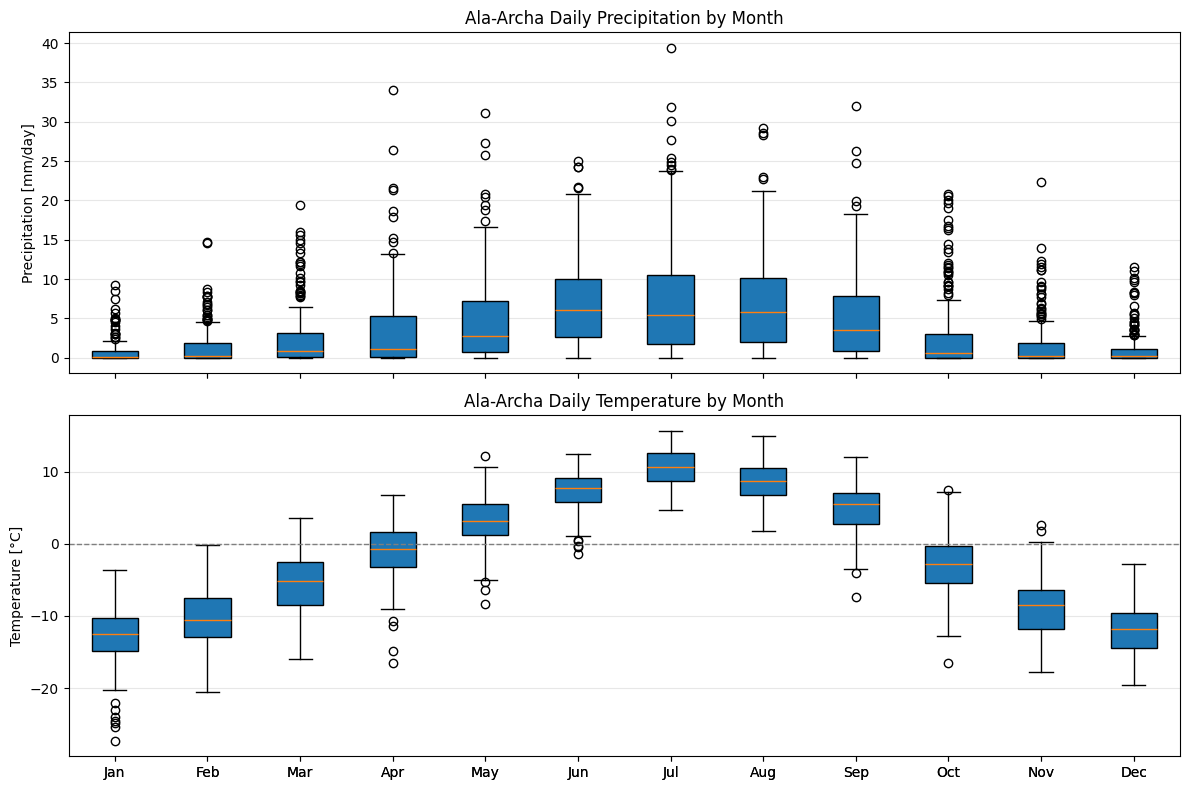

In [6]:
precipitation_by_month = [
    ala_archa_df.loc[ala_archa_df["month"] == month, "precipitation_mm"].to_numpy()
    for month in MONTHS
]

temperature_by_month = [
    ala_archa_df.loc[ala_archa_df["month"] == month, "temperature_degC"].to_numpy()
    for month in MONTHS
]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].boxplot(precipitation_by_month, tick_labels=MONTH_LABELS, patch_artist=True)
axes[0].set_ylabel("Precipitation [mm/day]")
axes[0].set_title("Ala-Archa Daily Precipitation by Month")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].boxplot(temperature_by_month, tick_labels=MONTH_LABELS, patch_artist=True)
axes[1].axhline(0.0, color="tab:gray", linestyle="--", linewidth=1.0)
axes[1].set_ylabel("Temperature [°C]")
axes[1].set_title("Ala-Archa Daily Temperature by Month")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The precipitation boxplots show that summer tends to have both **higher** daily precipitation and **more variability**.
The temperature boxplots show a very strong seasonal cycle, with many winter values below $0^\circ\mathrm{C}$.

This kind of plot does not tell us the exact value on one specific day.
Instead, it helps us see the **typical distribution** for each month.


### Exercise 2

Use `groupby(...)` to compute monthly mean values.

Store these three numbers:
- `ala_archa_january_mean_temp` as the mean January temperature
- `ala_archa_july_mean_temp` as the mean July temperature
- `ala_archa_july_mean_precip` as the mean July precipitation

Then print them.


In [7]:
ala_archa_monthly_means = ala_archa_df.groupby("month", observed=False)[
    ["precipitation_mm", "temperature_degC"]
].mean()

ala_archa_january_mean_temp = float(ala_archa_monthly_means.loc[1, "temperature_degC"])
ala_archa_july_mean_temp = float(ala_archa_monthly_means.loc[7, "temperature_degC"])
ala_archa_july_mean_precip = float(ala_archa_monthly_means.loc[7, "precipitation_mm"])

print(ala_archa_january_mean_temp)
print(ala_archa_july_mean_temp)
print(ala_archa_july_mean_precip)
print(ala_archa_monthly_means.round(3))

-12.811673387096775
10.731684229390682
7.091735483870968
       precipitation_mm  temperature_degC
month                                    
1                 0.704           -12.812
2                 1.378           -10.455
3                 2.322            -5.631
4                 3.405            -0.812
5                 4.619             3.311
6                 6.919             7.464
7                 7.092            10.732
8                 6.674             8.655
9                 5.122             4.842
10                2.654            -2.933
11                1.572            -9.017
12                1.062           -11.840


In [8]:
assert np.isclose(ala_archa_january_mean_temp, -12.811726923076924), (
    "The January mean temperature is not correct. Recheck your `groupby(...)` result."
)
assert np.isclose(ala_archa_july_mean_temp, 10.731732258064516), (
    "The July mean temperature is not correct."
)
assert np.isclose(ala_archa_july_mean_precip, 7.091735483870968), (
    "The July mean precipitation is not correct."
)
print("Exercise 2 checks passed.")

Exercise 2 checks passed.


## 3. Looking at Extreme Days

Seasonal summaries are helpful, but they can hide rare events.
Hydrology is often strongly influenced by extremes, such as:
- unusually wet days
- unusually hot days
- unusually cold days

A simple first step is to sort the DataFrame by one column and inspect the top or bottom rows.


In [9]:
wettest_days = ala_archa_df.nlargest(5, "precipitation_mm")[["date", "precipitation_mm", "temperature_degC"]]
hottest_days = ala_archa_df.nlargest(5, "temperature_degC")[["date", "temperature_degC", "precipitation_mm"]]
coldest_days = ala_archa_df.nsmallest(5, "temperature_degC")[["date", "temperature_degC", "precipitation_mm"]]

print("Wettest days")
print(wettest_days)
print()
print("Hottest days")
print(hottest_days)
print()
print("Coldest days")
print(coldest_days)

Wettest days
           date  precipitation_mm  temperature_degC
2597 2022-07-04           39.4028           14.0865
689  2017-04-13           33.9974           -4.2886
1568 2019-09-09           31.9910           -0.5368
2621 2022-07-28           31.8643           12.2696
1816 2020-05-14           31.1349            3.8247

Hottest days
           date  temperature_degC  precipitation_mm
2254 2021-07-26           15.6384            0.0009
2615 2022-07-22           15.5854            0.4741
2616 2022-07-23           15.5685            0.4106
775  2017-07-08           15.5629            1.8818
52   2015-07-16           15.4453            6.0940

Coldest days
           date  temperature_degC  precipitation_mm
2789 2023-01-12          -27.3011            0.0264
979  2018-01-28          -25.3635            0.1280
978  2018-01-27          -24.8818            0.1758
2790 2023-01-13          -24.5861            0.0056
2788 2023-01-11          -24.0707            3.0311


This is a good example of using `pandas` for quick data inspection.
You are not building a formal model here.
You are simply asking the data some direct questions.

For instance:
- Does the wettest day happen in summer?
- Are the coldest days nearly dry, or do they still have some precipitation?
- Do the hottest days line up with high or low precipitation?


### Exercise 3

Store these six values:
- `ala_archa_wettest_date` as the date of the wettest day
- `ala_archa_wettest_precip_mm` as the precipitation on the wettest day
- `ala_archa_hottest_date` as the date of the hottest day
- `ala_archa_hottest_temp_degC` as the temperature on the hottest day
- `ala_archa_coldest_date` as the date of the coldest day
- `ala_archa_coldest_temp_degC` as the temperature on the coldest day


In [10]:
ala_archa_wettest_row = ala_archa_df.loc[ala_archa_df["precipitation_mm"].idxmax()]
ala_archa_hottest_row = ala_archa_df.loc[ala_archa_df["temperature_degC"].idxmax()]
ala_archa_coldest_row = ala_archa_df.loc[ala_archa_df["temperature_degC"].idxmin()]

ala_archa_wettest_date = ala_archa_wettest_row["date"]
ala_archa_wettest_precip_mm = float(ala_archa_wettest_row["precipitation_mm"])
ala_archa_hottest_date = ala_archa_hottest_row["date"]
ala_archa_hottest_temp_degC = float(ala_archa_hottest_row["temperature_degC"])
ala_archa_coldest_date = ala_archa_coldest_row["date"]
ala_archa_coldest_temp_degC = float(ala_archa_coldest_row["temperature_degC"])

print(ala_archa_wettest_date, ala_archa_wettest_precip_mm)
print(ala_archa_hottest_date, ala_archa_hottest_temp_degC)
print(ala_archa_coldest_date, ala_archa_coldest_temp_degC)

2022-07-04 00:00:00 39.4028
2021-07-26 00:00:00 15.6384
2023-01-12 00:00:00 -27.3011


In [11]:
assert str(ala_archa_wettest_date.date()) == "2022-07-04", "The wettest Ala-Archa day should be 2022-07-04."
assert np.isclose(ala_archa_wettest_precip_mm, 39.4028), "The wettest-day precipitation is not correct."
assert str(ala_archa_hottest_date.date()) == "2021-07-26", "The hottest Ala-Archa day should be 2021-07-26."
assert np.isclose(ala_archa_hottest_temp_degC, 15.6384), "The hottest-day temperature is not correct."
assert str(ala_archa_coldest_date.date()) == "2023-01-12", "The coldest Ala-Archa day should be 2023-01-12."
assert np.isclose(ala_archa_coldest_temp_degC, -27.3011), "The coldest-day temperature is not correct."
print("Exercise 3 checks passed.")

Exercise 3 checks passed.


## 4. Potential Evapotranspiration with Oudin (2005)

So far we have only **described** the data.
Now we will compute a new hydrological variable from an equation.

Potential evapotranspiration (PET) is a simplified estimate of how much water the atmosphere could remove from the surface under the given energy conditions.
In this notebook we will use the **Oudin** temperature-based formula.

A temperature-only PET estimate requiring just mean daily temperature $T$ in $^\circ\mathrm{C}$, day of year $J$, and station latitude $\phi$ in radians.

### Extraterrestrial radiation $R_a$

| Quantity | Formula |
|---|---|
| Solar declination | $\delta = 0.4093 \sin\left(\frac{2\pi J}{365} - 1.405\right)$ |
| Sunset hour angle | $\omega_s = \arccos(-\tan\phi\,\tan\delta)$ |
| Inverse relative distance | $d_r = 1 + 0.033\cos\left(\frac{2\pi J}{365}\right)$ |

$$
R_a = \frac{24 \times 60}{\pi}\, G_{sc}\, d_r
      \left[\omega_s \sin\phi\,\sin\delta
            + \cos\phi\,\cos\delta\,\sin\omega_s\right]
$$

where $G_{sc} = 0.0820\,\mathrm{MJ\,m^{-2}\,min^{-1}}$.

### PET

$$
\operatorname{PET} =
\begin{cases}
\frac{R_a}{\lambda}\,\frac{T + 5}{100}
  & \text{if } T + 5 > 0 \\[6pt]
0 & \text{otherwise}
\end{cases}
$$

with $\lambda = 2.45\,\mathrm{MJ\,kg^{-1}}$ (latent heat of vaporisation).

The important idea here is not memorising every symbol.
The important idea is learning how to move from a mathematical description to Python code.


In [12]:
GSC = 0.0820
LAMBDA = 2.45


def extraterrestrial_radiation(doy: np.ndarray, lat_rad: float) -> np.ndarray:
    dr = 1.0 + 0.033 * np.cos(2.0 * np.pi / 365.0 * doy)
    delta = 0.4093 * np.sin(2.0 * np.pi / 365.0 * doy - 1.405)
    ws = np.arccos(-np.tan(lat_rad) * np.tan(delta))
    return (
        (24.0 * 60.0 / np.pi)
        * GSC
        * dr
        * (ws * np.sin(lat_rad) * np.sin(delta) + np.cos(lat_rad) * np.cos(delta) * np.sin(ws))
    )

The `extraterrestrial_radiation(...)` function follows the equation step by step.
Each intermediate quantity in the formula becomes one Python variable.

That is often the clearest way to implement scientific equations:
- compute a few named pieces
- combine them into the final expression
- test whether the result looks reasonable


### Exercise 4

Store these two values:
- `ala_archa_latitude_rad` as the Ala-Archa latitude converted from degrees to radians
- `ala_archa_first_day_ra` as extraterrestrial radiation for the first row in the DataFrame

Use `day_of_year` from the first Ala-Archa row.


In [13]:
ala_archa_latitude_rad = np.radians(ALA_ARCHA_GAUGE_LAT)
ala_archa_first_day_ra = float(
    extraterrestrial_radiation(
        np.array([ala_archa_df.loc[0, "day_of_year"]]),
        ala_archa_latitude_rad,
    )[0]
)

print(ala_archa_latitude_rad)
print(ala_archa_first_day_ra)

0.744557458900781
40.55051701661772


In [14]:
assert np.isclose(ala_archa_latitude_rad, 0.7445602701756736), "The latitude conversion to radians is not correct."
assert np.isclose(ala_archa_first_day_ra, 40.55051701661772), "The first-day extraterrestrial radiation is not correct."
print("Exercise 4 checks passed.")

Exercise 4 checks passed.


In [15]:
def oudin_pet(temp: np.ndarray, doy: np.ndarray, latitude_deg: float) -> np.ndarray:
    lat_rad = np.radians(latitude_deg)
    ra = extraterrestrial_radiation(doy, lat_rad)
    return np.where(temp + 5.0 > 0.0, ra / LAMBDA * (temp + 5.0) / 100.0, 0.0)


ala_archa_df["pet_mm"] = oudin_pet(
    ala_archa_df["temperature_degC"].to_numpy(),
    ala_archa_df["day_of_year"].to_numpy(),
    ALA_ARCHA_GAUGE_LAT,
)

print(ala_archa_df[["date", "temperature_degC", "day_of_year", "pet_mm"]].head())
print(ala_archa_df["pet_mm"].describe())

        date  temperature_degC  day_of_year    pet_mm
0 2015-05-25            0.2445          145  0.868029
1 2015-05-26            1.4076          146  1.063157
2 2015-05-27            2.9302          147  1.318910
3 2015-05-28            4.2443          148  1.540962
4 2015-05-29            5.7689          149  1.799013
count    3049.000000
mean        0.910722
std         0.991729
min         0.000000
25%         0.000000
50%         0.492730
75%         1.770666
max         3.471500
Name: pet_mm, dtype: float64


Now Ala-Archa has a new `pet_mm` column.

A few useful interpretation questions are:
- Is PET always non-negative?
- Is PET zero on very cold days?
- Is PET larger in summer than in winter?

Those are both **coding** questions and **hydrological** questions.


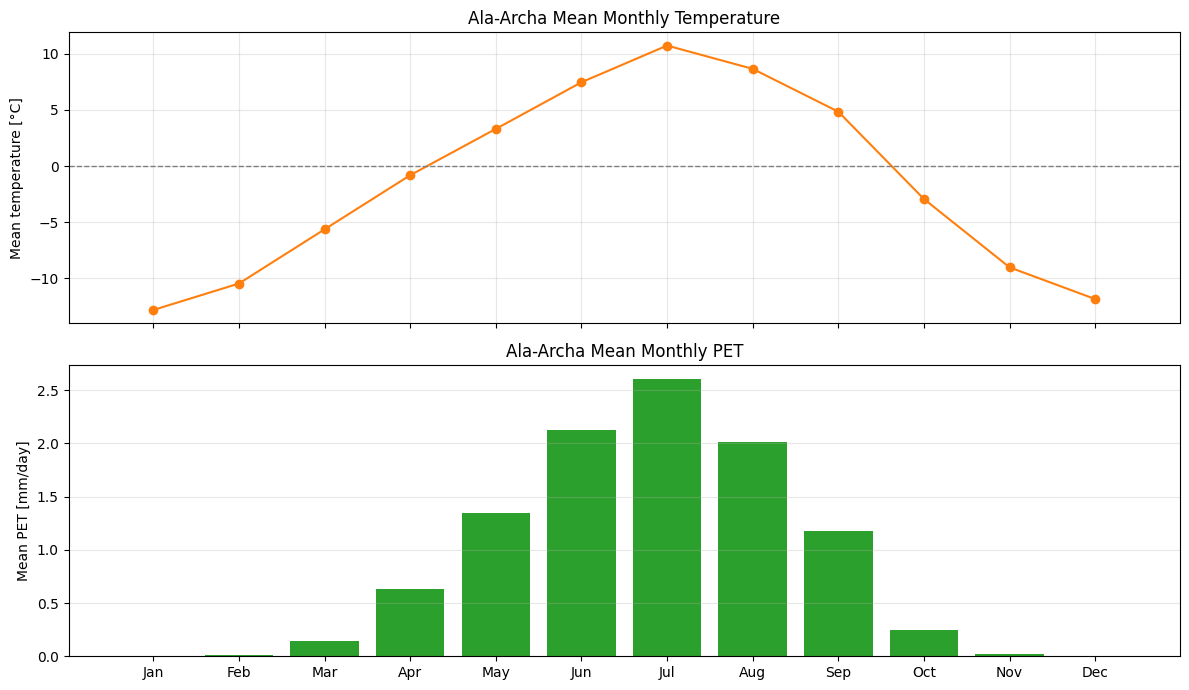

In [16]:
ala_archa_monthly_pet = ala_archa_df.groupby("month", observed=False)["pet_mm"].mean()
ala_archa_monthly_temp = ala_archa_df.groupby("month", observed=False)["temperature_degC"].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(MONTHS, ala_archa_monthly_temp.values, marker="o", color="tab:orange")
axes[0].axhline(0.0, color="tab:gray", linestyle="--", linewidth=1.0)
axes[0].set_ylabel("Mean temperature [°C]")
axes[0].set_title("Ala-Archa Mean Monthly Temperature")
axes[0].grid(True, alpha=0.3)

axes[1].bar(MONTHS, ala_archa_monthly_pet.values, color="tab:green")
axes[1].set_xticks(MONTHS, MONTH_LABELS)
axes[1].set_ylabel("Mean PET [mm/day]")
axes[1].set_title("Ala-Archa Mean Monthly PET")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 5

Store these four values:
- `ala_archa_pet_zero_days` as the number of days with `pet_mm == 0.0`
- `ala_archa_first_pet_mm` as the first PET value in the DataFrame
- `ala_archa_max_pet_mm` as the maximum PET value in the DataFrame
- `ala_archa_july_mean_pet_mm` as the mean July PET value

Then print them.


In [17]:
ala_archa_pet_zero_days = int((ala_archa_df["pet_mm"] == 0.0).sum())
ala_archa_first_pet_mm = float(ala_archa_df.loc[0, "pet_mm"])
ala_archa_max_pet_mm = float(ala_archa_df["pet_mm"].max())
ala_archa_july_mean_pet_mm = float(ala_archa_monthly_pet.loc[7])

print(ala_archa_pet_zero_days)
print(ala_archa_first_pet_mm)
print(ala_archa_max_pet_mm)
print(ala_archa_july_mean_pet_mm)

1133
0.8680293326271494
3.4715002328985123
2.6027616937686044


In [18]:
assert ala_archa_pet_zero_days == 1133, "The number of zero-PET days is not correct."
assert np.isclose(ala_archa_first_pet_mm, 0.8680293326271494), "The first PET value is not correct."
assert np.isclose(ala_archa_max_pet_mm, 3.4715002328985123), "The maximum PET value is not correct."
assert np.isclose(ala_archa_july_mean_pet_mm, 2.6027616937686044), "The mean July PET value is not correct."
print("Exercise 5 checks passed.")

Exercise 5 checks passed.


## 5. A Simple Discharge Seasonality View

Notebook 6 mainly focuses on forcing data and PET.
Still, it is helpful to include **one** discharge-based seasonal summary so we keep the hydrological response in view.

Here is the idea:
1. take `q_mm_clean`
2. drop missing discharge values
3. compute one **monthly mean discharge** for each year-month
4. group those monthly means by calendar month
5. show them as boxplots

This gives a compact view of the seasonal discharge cycle without getting lost in the day-to-day noise.


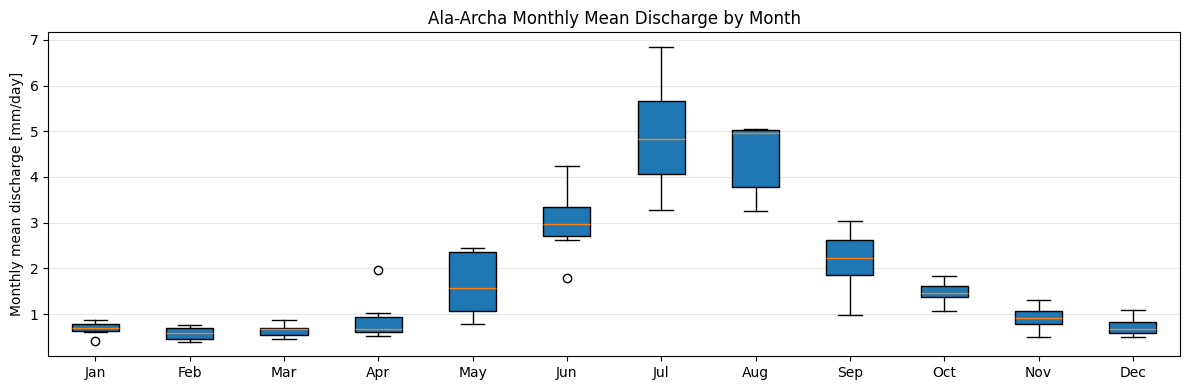

   year  month  monthly_mean_q_mm
0  2015      5           1.441498
1  2015      6           2.753663
2  2015      9           0.982562
3  2015     10           1.603697
4  2015     11           1.237814


In [19]:
ala_archa_monthly_flow_df = (
    ala_archa_df.dropna(subset=["q_mm_clean"])
    .assign(
        year=lambda df: df["date"].dt.year,
        month=lambda df: df["date"].dt.month,
    )
    .groupby(["year", "month"], as_index=False, observed=False)["q_mm_clean"]
    .mean()
    .rename(columns={"q_mm_clean": "monthly_mean_q_mm"})
)

monthly_mean_flow_by_month = [
    ala_archa_monthly_flow_df.loc[
        ala_archa_monthly_flow_df["month"] == month,
        "monthly_mean_q_mm",
    ].to_numpy()
    for month in MONTHS
]

fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(monthly_mean_flow_by_month, tick_labels=MONTH_LABELS, patch_artist=True)
ax.set_ylabel("Monthly mean discharge [mm/day]")
ax.set_title("Ala-Archa Monthly Mean Discharge by Month")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(ala_archa_monthly_flow_df.head())

This plot should show a strong seasonal signal.
For a glacier- and snow-influenced basin like Ala-Archa, it is reasonable to expect larger monthly mean discharge in the warm season than in mid-winter.

Again, the point is not only to make a plot.
The point is to ask whether the pattern makes physical sense.


### Exercise 6

Store these three values:
- `ala_archa_monthly_flow_rows` as the number of year-month rows in `ala_archa_monthly_flow_df`
- `ala_archa_monthly_flow_has_nan` as whether `monthly_mean_q_mm` still contains any missing values
- `ala_archa_august_median_monthly_flow` as the median August monthly mean discharge

Then print them.


In [20]:
ala_archa_monthly_flow_rows = len(ala_archa_monthly_flow_df)
ala_archa_monthly_flow_has_nan = bool(ala_archa_monthly_flow_df["monthly_mean_q_mm"].isna().any())
ala_archa_august_median_monthly_flow = float(
    ala_archa_monthly_flow_df.loc[
        ala_archa_monthly_flow_df["month"] == 8,
        "monthly_mean_q_mm",
    ].median()
)

print(ala_archa_monthly_flow_rows)
print(ala_archa_monthly_flow_has_nan)
print(ala_archa_august_median_monthly_flow)

88
False
4.964200939123035


In [21]:
assert ala_archa_monthly_flow_rows == 88, "The monthly-flow summary should have 88 year-month rows."
assert ala_archa_monthly_flow_has_nan is False, "Monthly mean discharge should not contain NaN values after dropping missing days first."
assert np.isclose(ala_archa_august_median_monthly_flow, 4.96420062498357), (
    "The median August monthly mean discharge is not correct."
)
print("Exercise 6 checks passed.")

Exercise 6 checks passed.


## 6. Open Exploration for Alamedin

Up to this point, the notebook has been highly guided.
Now the goal changes slightly.

For **Alamedin**, you should use the ideas from Ala-Archa and explore the basin more independently.
You do not need to copy everything exactly.
Instead, choose one or two plots that help you understand the data.


In [22]:
alamedin_path = DATA_ROOT / ALAMEDIN_FOLDER / "03_processed" / "cleaned_daily_dataset.csv"
alamedin_df = pd.read_csv(alamedin_path, parse_dates=["date"])

alamedin_df["month"] = alamedin_df["date"].dt.month
alamedin_df["day_of_year"] = alamedin_df["date"].dt.dayofyear
alamedin_df["pet_mm"] = oudin_pet(
    alamedin_df["temperature_degC"].to_numpy(),
    alamedin_df["day_of_year"].to_numpy(),
    ALAMEDIN_GAUGE_LAT,
)

print(alamedin_path)
print(alamedin_df.head())
print(alamedin_df[["precipitation_mm", "temperature_degC", "pet_mm", "q_mm_clean"]].describe())

/Users/nicolaslazaro/Desktop/2025_02_TW_ETHZ_CA_IWRM/02_data/15189_Alamedin_River_KGZ/03_processed/cleaned_daily_dataset.csv
        date  precipitation_mm  temperature_degC     q_m3s      q_mm  \
0 2015-05-26            1.5501            2.1384  5.012799  1.033838   
1 2015-05-27            0.7998            3.6485  4.831027  0.996350   
2 2015-05-28            2.1731            4.7358  4.831027  0.996350   
3 2015-05-29            0.8779            6.3808  4.831027  0.996350   
4 2015-05-30            1.2886            6.3067  5.291750  1.091369   

   q_gap_length_days  q_mm_clean  q_status  month  day_of_year    pet_mm  
0                  0    1.033838  observed      5          146  1.184354  
1                  0    0.996350  observed      5          147  1.438310  
2                  0    0.996350  observed      5          148  1.622826  
3                  0    0.996350  observed      5          149  1.901164  
4                  0    1.091369  observed      5          150  1.8

### Your Alamedin Exploration

Choose at least **two** of the following ideas:

- recreate one Ala-Archa plot for Alamedin and compare what changes
- make a monthly boxplot of precipitation, temperature, or monthly mean discharge
- find the wettest, hottest, and coldest Alamedin days
- plot monthly mean PET and compare it to monthly mean temperature
- make a bar plot of daily precipitation where the bar color depends on temperature
- create a very simple exploratory snow/rain split by saying:
  - snow if `temperature_degC < 0`
  - rain otherwise
- plot the estimated snow and rain amounts separately and ask whether the pattern looks reasonable

That last rule is only a **simple exploratory idea**.
It is not the formal snow routine used later in the model.


### Using AI Carefully

It is completely fine to use AI to help with:
- Python syntax
- `matplotlib` arguments
- `pandas` grouping patterns

But AI should not replace your thinking.
You still need to decide:
- what question you are asking
- whether the plot answers that question
- whether the result makes hydrological sense

A good workflow is:
1. decide what you want to inspect
2. ask AI for help with the code shape if needed
3. run the code yourself
4. interpret the result in your own words


## Wrap-Up

In this notebook you practiced how to move from a cleaned daily dataset to a few useful hydrological summaries.

You worked with:
- calendar features such as month and day of year
- monthly boxplots for precipitation and temperature
- `groupby(...)` summaries for seasonal signals
- extreme-day inspection with sorting
- Oudin PET computed from equations
- a compact monthly discharge seasonality view

That is a useful bridge between basic Python practice and later hydrological preprocessing.
You are no longer only reading tables.
You are starting to ask the data hydrologically meaningful questions.
